# Chi-Square Test of Independence

This continues from the [Chi-Square Goodness of Fit notebook](15_Hypothesis_Testing_Chi_Square_Test.ipynb), which tested whether **one** categorical variable (a die's face) matched an expected distribution. This notebook covers the **second** situation mentioned there — **Independence** — which tests whether **two categorical variables** are associated with each other, or independent.

The formula is exactly the same:

$$\chi^2 = \sum \dfrac{(O_i - E_i)^2}{E_i}$$

What changes is *how the categories are laid out* (a **contingency table** — rows × columns — instead of a single list) and *how the expected frequencies $E_i$ are computed* (from row/column totals, instead of an even split).

## Example 2 (Independence, Chi-Square Test)

A study was conducted to investigate whether there is a relationship between **gender** and the **preferred genre of music**. A sample of **235 people** was selected, and the data collected is shown below. Test at a **5% level of significance** whether there is a significant association between gender and music preference.

| | Pop | Hip Hop | Classical | Rock | **Row Total** |
|---|---|---|---|---|---|
| **Male** | 40 | 45 | 25 | 10 | **120** |
| **Female** | 35 | 30 | 20 | 30 | **115** |
| **Column Total** | 75 | 75 | 45 | 40 | **235** |

### Step 1 - State the Null and Alternate Hypothesis

$$H_0: \text{gender and music preference are independent (no association)}$$
$$H_1: \text{gender and music preference are associated}$$

- $H_0$ (Null Hypothesis) — a person's preferred genre does **not** depend on their gender; any difference between observed and expected counts is just random sampling variation.
- $H_1$ (Alternate Hypothesis) — preference **does** depend on gender; the two variables are related.

Just like the Goodness of Fit test, this is a **one-tailed (right-tail only)** test — $\chi^2$ can never be negative, so only large deviations (evidence *of* association) push into the rejection region.

### Step 2 - Significance Value

$$\alpha = 0.05$$

As before, the entire 5% sits in the **right tail** of the Chi-Square distribution — there's no "too independent" side to split it with.

### Step 3 - Degrees of Freedom

$$df = (\text{rows}-1)(\text{cols}-1) = (2-1)(4-1) = 3$$

For the **Independence** test, `df` depends on **both** dimensions of the contingency table: 2 rows (Male/Female) and 4 columns (Pop/Hip Hop/Classical/Rock). This differs from the Goodness of Fit formula ($df=k-1$) because once the row and column totals are fixed, only $(r-1)(c-1)$ of the interior cells are free to vary — every other cell is forced by the margins that must add up to those fixed totals.

### Step 4 - Observed vs Expected Frequencies, and the Chi-Square Statistic

**Observed ($O$):** the raw contingency table counts — `row1` = Male counts, `row2` = Female counts.

**Expected ($E$):** if gender and genre really were independent, each cell's expected count is driven purely by its **row total** and **column total** relative to the **grand total** (235):

$$E_{row,col} = \dfrac{(\text{row total}) \times (\text{column total})}{\text{grand total}}$$

Intuitively: if 120/235 people are Male overall, and 75/235 people overall prefer Pop, then under independence we'd expect $235 \times \frac{120}{235} \times \frac{75}{235} = \frac{120 \times 75}{235} \approx 38.3$ Male-Pop respondents. The cells below compute the row sums, column sums, and every $E_{row,col}$ from that formula, then $\chi^2_{calc} = \sum \frac{(O-E)^2}{E}$ across all 8 cells.

In [1]:
import numpy as np

In [2]:
row1 = np.array([40,45,25,10])

In [3]:
row2 = np.array([35,30,20,30])

In [4]:
sum_rows1 = np.sum(row1) 
sum_rows2 = np.sum(row2) 
sum_rows1, sum_rows2

(np.int64(120), np.int64(115))

In [5]:
sum_rows = row1 + row2 
sum_rows

array([75, 75, 45, 40])

In [6]:
sum_row = np.array([sum_rows1,sum_rows2])
sum_row

array([120, 115])

In [7]:

exp = []
for i in sum_row:
    for j in sum_rows:
        value = (i*j)/235
        exp.append(value)

exp

[np.float64(38.297872340425535),
 np.float64(38.297872340425535),
 np.float64(22.97872340425532),
 np.float64(20.425531914893618),
 np.float64(36.702127659574465),
 np.float64(36.702127659574465),
 np.float64(22.02127659574468),
 np.float64(19.574468085106382)]

In [8]:
obj = np.array([40,45,25,10,35,30,20,30])
obj

array([40, 45, 25, 10, 35, 30, 20, 30])

In [9]:
substract = obj-exp
substract

array([  1.70212766,   6.70212766,   2.0212766 , -10.42553191,
        -1.70212766,  -6.70212766,  -2.0212766 ,  10.42553191])

In [10]:
np.sum(np.square(substract)/exp)

np.float64(13.788747987117553)

$$\chi^2_{calc} \approx 13.79$$

### Step 5 - Decision Boundary (Critical $\chi^2$ Value)

Look up the Chi-Square table at **df = 3**, right-tail $\alpha = 0.05$:

$$\chi^2_{table} \approx 7.815$$

Anything **below** 7.815 falls in the **acceptance region** (fail to reject $H_0$); anything **at or above** it falls in the **rejection region** (reject $H_0$).

In [11]:
import scipy.stats as st

rows = 2
cols = 4
df = (rows - 1) * (cols - 1)   # 3
alpha = 0.05

chi_calc = np.sum(np.square(substract) / exp)   # same value computed above
chi_critical = st.chi2.ppf(1 - alpha, df)         # ~7.815

print("df:", df)
print("chi_calc:", round(chi_calc, 4))
print("chi_critical:", round(chi_critical, 4))

df: 3
chi_calc: 13.7887
chi_critical: 7.8147


### Step 6 - Decision & Conclusion

**Decision rule:** If $\chi^2_{calc}$ is greater than $\chi^2_{table}$, reject the null hypothesis.

$$\chi^2_{calc} (13.79) \; vs \; \chi^2_{table} (7.815)$$

$13.79 > 7.815$, so $\chi^2_{calc}$ falls in the **rejection region** → **reject $H_0$**.

**Conclusion:** At the 5% level of significance, there **is enough evidence** to say gender and music preference are associated. The observed genre preferences differ from what independence would predict by more than random sampling variation can explain — e.g. Rock skews strongly Female (30 vs. an expected ~19.6) while Pop/Hip Hop skew Male.

In [12]:
if chi_calc > chi_critical:
    print("Reject H0 -> H1 is right (gender and music preference ARE associated)")
else:
    print("Fail to reject H0 -> H0 holds (no significant association, at alpha=0.05)")

Reject H0 -> H1 is right (gender and music preference ARE associated)


### Visualizing the Chi-Square Distribution (df = 3)

Where does $\chi^2_{calc}=13.79$ land relative to the rejection region (right tail beyond $\chi^2_{table}=7.815$)? Note this distribution (df=3) is shaped differently from the df=5 one in the [Goodness of Fit notebook](15_Hypothesis_Testing_Chi_Square_Test.ipynb) — with fewer degrees of freedom the peak sits closer to 0 and the tail is thinner, so a given $\chi^2$ value crosses into "significant" territory faster.

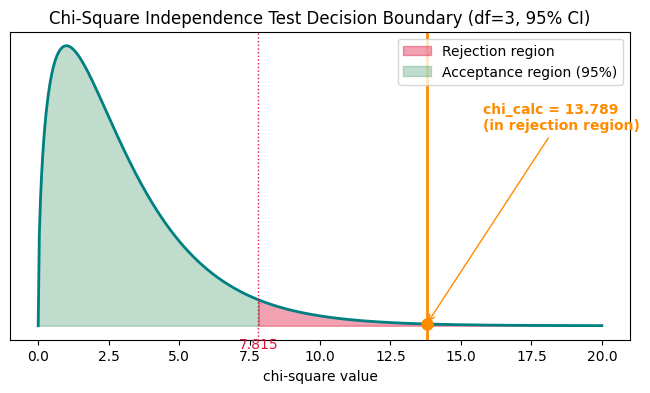

In [13]:
import matplotlib.pyplot as plt

x = np.linspace(0, 20, 500)
y = st.chi2.pdf(x, df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, color="teal", linewidth=2)

# rejection region - right tail only
x_reject = np.linspace(chi_critical, 20, 100)
ax.fill_between(x_reject, st.chi2.pdf(x_reject, df), color="crimson", alpha=0.4, label="Rejection region")

# acceptance region
x_accept = np.linspace(0, chi_critical, 200)
ax.fill_between(x_accept, st.chi2.pdf(x_accept, df), color="seagreen", alpha=0.3, label="Acceptance region (95%)")

ax.axvline(chi_critical, color="crimson", linestyle=":", linewidth=1)
ax.text(chi_critical, -0.01, f"{chi_critical:.3f}", ha="center", va="top", color="crimson")

ax.axvline(chi_calc, color="darkorange", linewidth=2)
ax.plot(chi_calc, st.chi2.pdf(chi_calc, df), "o", color="darkorange", markersize=8, zorder=5)
ax.annotate(f"chi_calc = {chi_calc:.3f}\n(in rejection region)",
            xy=(chi_calc, st.chi2.pdf(chi_calc, df)),
            xytext=(chi_calc + 2, max(y) * 0.7),
            arrowprops=dict(arrowstyle="->", color="darkorange"),
            color="darkorange", fontweight="bold")

ax.legend()
ax.set_yticks([])
ax.set_xlabel("chi-square value")
ax.set_title(f"Chi-Square Independence Test Decision Boundary (df={df}, 95% CI)")
plt.show()

### Visualizing Observed vs Expected Counts (Where the Association Comes From)

The distribution plot above shows *that* $\chi^2_{calc}$ is significant, but not *why*. The chart below puts **Observed** next to **Expected** for every gender × genre cell — the bigger the gap between the two bars, the more that cell is pulling $\chi^2_{calc}$ upward. Rock immediately stands out: Females observed at 30 vs. an expected ~19.6, and Males observed at only 10 vs. an expected ~20.4.

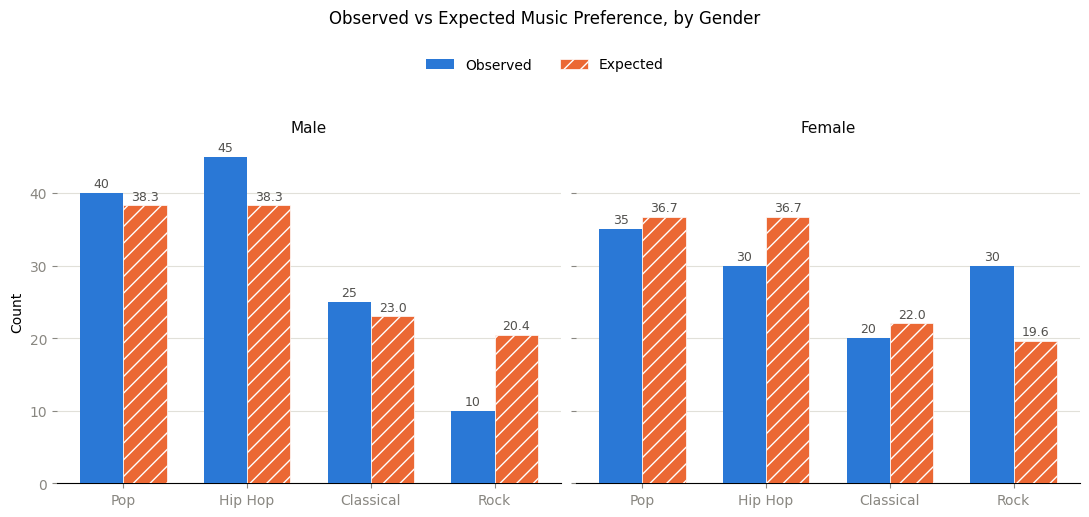

In [14]:
genres = ["Pop", "Hip Hop", "Classical", "Rock"]
male_exp = np.array(exp[:4])
female_exp = np.array(exp[4:])

color_obs = "#2a78d6"   # Observed
color_exp = "#eb6834"   # Expected (hatched, since it's a derived/theoretical value)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
bar_width = 0.35
x = np.arange(len(genres))

for ax, obs_vals, exp_vals, title in zip(axes, [row1, row2], [male_exp, female_exp], ["Male", "Female"]):
    bars_obs = ax.bar(x - bar_width/2, obs_vals, bar_width, label="Observed", color=color_obs, zorder=3)
    bars_exp = ax.bar(x + bar_width/2, exp_vals, bar_width, label="Expected", color=color_exp,
                       hatch="//", edgecolor="white", linewidth=0.5, zorder=3)

    ax.bar_label(bars_obs, fmt="%.0f", padding=2, fontsize=9, color="#52514e")
    ax.bar_label(bars_exp, fmt="%.1f", padding=2, fontsize=9, color="#52514e")

    ax.set_xticks(x)
    ax.set_xticklabels(genres)
    ax.set_title(title, fontsize=11, color="#0b0b0b")
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(colors="#898781")

axes[0].set_ylabel("Count")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.06))
fig.suptitle("Observed vs Expected Music Preference, by Gender", y=1.14, fontsize=12)
plt.tight_layout()
plt.show()

### Cross-Check with `scipy.stats`

For the Independence test, `scipy.stats.chi2_contingency` takes the **raw contingency table** directly (no manual row/column-sum loop needed), and returns the statistic, the **p-value**, `dof`, and the full expected-frequency table in one call — useful for confirming the manual calculation above.

In [15]:
observed_table = np.array([row1, row2])   # 2 x 4 contingency table

scipy_chi2, scipy_p, scipy_dof, scipy_expected = st.chi2_contingency(observed_table)

print("scipy chi-square statistic:", scipy_chi2)
print("scipy dof:", scipy_dof)
print("scipy p-value:", scipy_p)
print("scipy expected frequencies:\n", scipy_expected)
print("p-value <= alpha (0.05)?", scipy_p <= alpha, "-> reject H0" if scipy_p <= alpha else "-> fail to reject H0")

scipy chi-square statistic: 13.788747987117553
scipy dof: 3
scipy p-value: 0.003207271194419188
scipy expected frequencies:
 [[38.29787234 38.29787234 22.9787234  20.42553191]
 [36.70212766 36.70212766 22.0212766  19.57446809]]
p-value <= alpha (0.05)? True -> reject H0


---

## FAQ

**1. Why does $E_{row,col} = \dfrac{\text{row total} \times \text{col total}}{\text{grand total}}$ represent "no association"?**

If gender and genre were truly independent, $P(\text{Male and Pop}) = P(\text{Male}) \times P(\text{Pop})$ (the multiplication rule for independent events). Multiplying that joint probability back out by the grand total (235) gives exactly $\frac{\text{row total} \times \text{col total}}{\text{grand total}}$. So $E$ isn't an arbitrary formula — it's "what the counts would look like if the two variables truly didn't interact," which is the whole premise of $H_0$.

**2. Why is $df=(r-1)(c-1)=3$ and not, say, $8-1=7$ (treating all 8 cells like one flat list)?**

Unlike the Goodness of Fit test's single running total, here **both** the row totals (120, 115) *and* the column totals (75, 75, 45, 40) are fixed by the data. Once you fill in $(r-1)(c-1)=3$ cells freely, every remaining cell in that row/column is forced so the margins still add up correctly — so only 3 cells actually carry new information, not 7.

**3. This example's $\chi^2_{calc}=13.79$ comfortably clears $\chi^2_{table}=7.815$ — how strong is the association, not just "significant"?**

Statistical significance only says the association is unlikely to be pure chance; it says nothing about *size*. For that, a standardized effect-size measure like **Cramér's V** is used: $V = \sqrt{\dfrac{\chi^2}{n \times \min(r-1, c-1)}}$. Here $V = \sqrt{13.79 / (235 \times 1)} \approx 0.24$, which by conventional (Cohen's) thresholds is a **small-to-moderate** association — real, but not overwhelming (contrast with, say, $V > 0.5$).

**4. Does rejecting $H_0$ tell us gender *causes* a genre preference?**

No — this test only detects **association**, not **causation**. A significant $\chi^2$ means the variables aren't distributed independently in this sample; it says nothing about *why* (e.g. cultural exposure, marketing, sampling quirks in how the 235 people were recruited). Same caveat that applies to correlation in the [T-Test notebooks](09_Hypothesis_Testing_T-Test.ipynb) applies here.

**5. What if the observed counts had matched the expected counts almost exactly?**

Then $\chi^2_{calc}$ would land near 0, well inside the acceptance region, and the conclusion would flip to "fail to reject $H_0$" — no evidence of association, same as the fair-die result in the [Goodness of Fit notebook](15_Hypothesis_Testing_Chi_Square_Test.ipynb). Try shrinking the gaps in `row1`/`row2` above (e.g. making Female Rock closer to its ~19.6 expected value) and re-running to watch $\chi^2_{calc}$ drop toward — and eventually below — 7.815.